# 07 · Actions, conditions, and lifecycle

## Learning objectives

- Write a stateful behavior.
- Observe setup, initialise, update, and terminate.
- Separate completion from interruption.

**Environment:** the standalone Python kernel from the README. No ROS installation or sourcing is needed. Run all cells from top to bottom; each notebook starts with its own state.

## Intuition

An action may need to open a connection once, start work each time it is entered, poll
progress on each tick, and cancel work when interrupted. These are different moments:
`setup()` prepares resources; `initialise()` begins an invocation; `update()` reports progress;
`terminate(new_status)` handles leaving RUNNING or invalidation. Setup is not repeated on
every tick. An already terminal behavior starts a fresh invocation when ticked again.

In [2]:
import py_trees as pt
from behavior_trees_tutorial.behaviors.common import Function, CountTicks, Status
from behavior_trees_tutorial.visualization import diagram, trace, playground
from IPython.display import display

## Minimal working example

1 Wait two ticks: RUNNING
2 Wait two ticks: SUCCESS
['setup', 'initialise', 'update: 1 left', 'update: 0 left', 'terminate: SUCCESS']


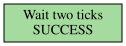

In [3]:
class Countdown(pt.behaviour.Behaviour):
    def __init__(self, name):
        super().__init__(name)
        self.events = []

    def setup(self, **kwargs):
        self.events.append("setup")

    def initialise(self):
        self.remaining = 2
        self.events.append("initialise")

    def update(self):
        self.remaining -= 1
        self.events.append(f"update: {self.remaining} left")
        return Status.SUCCESS if self.remaining == 0 else Status.RUNNING

    def terminate(self, new_status):
        self.events.append(f"terminate: {new_status.name}")

root = Countdown("Wait two ticks")
root.setup()
trace(root, 2)
print(root.events)
display(diagram(root))

## Step-by-step implementation
A third tick starts the action again. Stopping with INVALID means the parent withdrew its
request. In a real action, terminate would release or cancel resources; it would not undo
already completed physical effects. Conditions normally just read state and return immediately.

In [4]:
root.tick_once()
root.stop(Status.INVALID)
print(root.events)
assert root.events[-1] == "terminate: INVALID"
assert root.events.count("initialise") == 2
battery = {"charge": 0.8}
condition = Function("Enough charge?", lambda: Status.SUCCESS if battery["charge"] > 0.2 else Status.FAILURE)
condition.tick_once()
assert condition.status is Status.SUCCESS

['setup', 'initialise', 'update: 1 left', 'update: 0 left', 'terminate: SUCCESS', 'initialise', 'update: 1 left', 'terminate: INVALID']


## Interactive demonstration

In [5]:
display(playground(lambda: Countdown("Countdown")))

## Key observations

initialise happens on entry, not while an action remains RUNNING. Interruption must be implemented by the resource-owning action.

## Exercises

1. Add an event for resource cleanup.
2. Interrupt after one tick and check that the next invocation starts at two again.

Hints and worked solutions: `exercises/README.md` and `solutions/README.md` (lesson 07).

## Summary

Lifecycle hooks give stateful work a clear owner. Decorators can now change a child’s policy without rewriting its work.